In [192]:
import pandas as pd

df = pd.read_csv("csv/tpcp_3x5_epoch_metrics_save.csv")


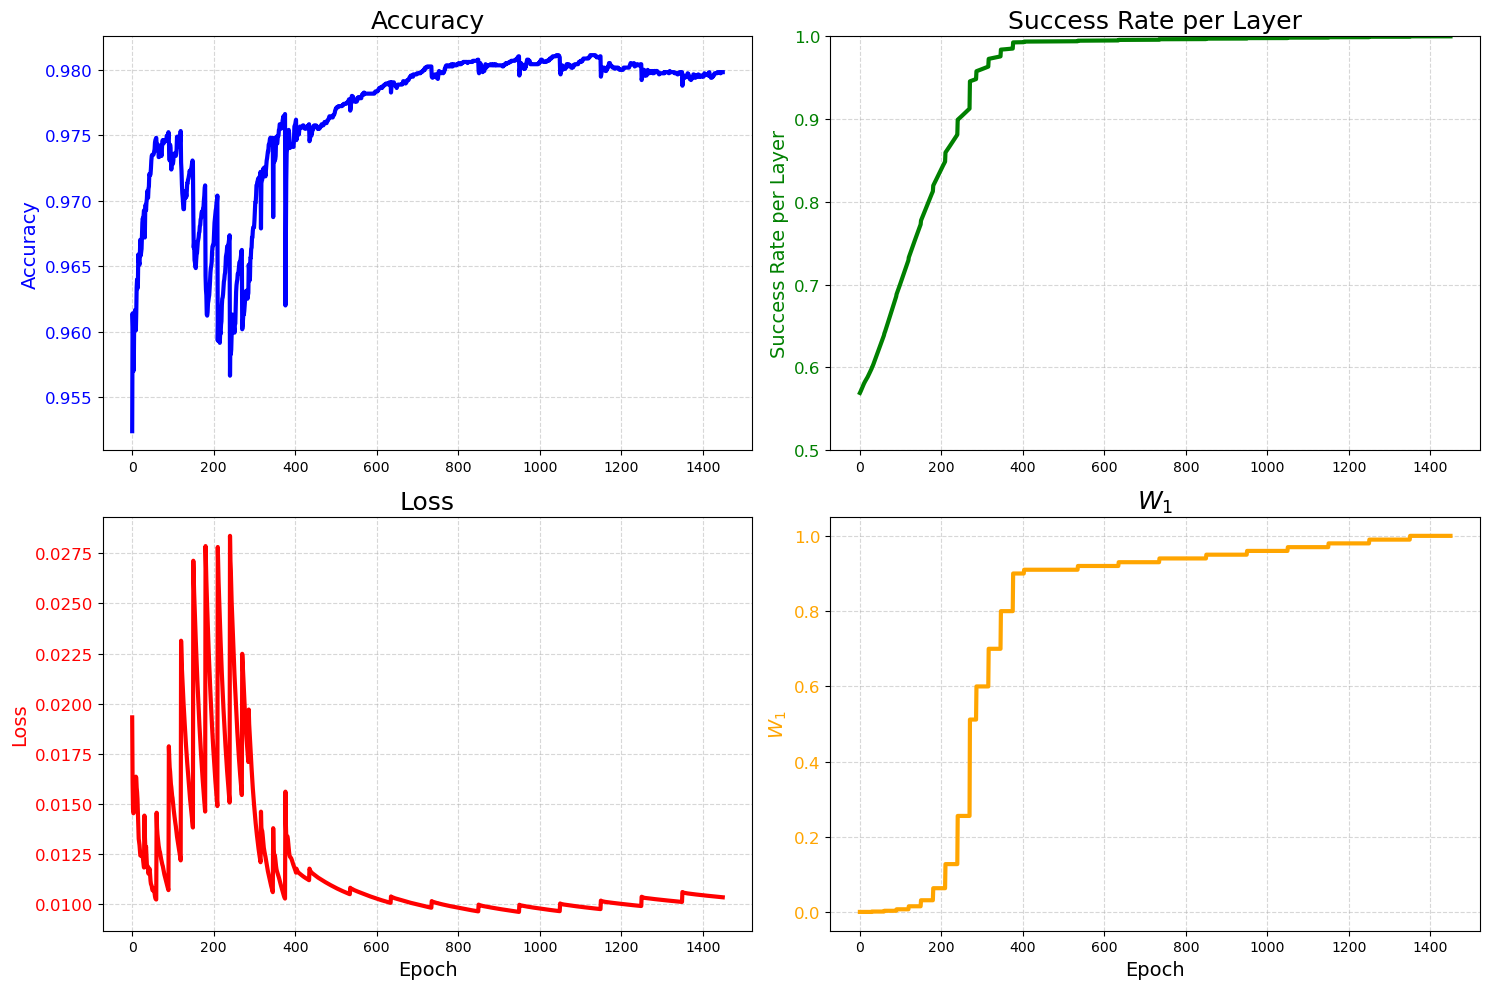

In [195]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is in a DataFrame called 'df'
# If you need to load data, uncomment and modify the following line:
# df = pd.read_csv('your_data.csv')

# Create a figure with 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 10))


# Plot Accuracy
axs[0, 0].plot(df.index, df['avg_acc'], linewidth=3, label='Accuracy', color='blue')
# axs[0, 0].set_xlabel('Epoch', fontsize=14)
axs[0, 0].set_ylabel('Accuracy', fontsize=14, color='blue')
axs[0, 0].tick_params(axis='y', labelcolor='blue', labelsize=12)
axs[0, 0].grid(True, linestyle='--', alpha=0.5)
axs[0, 0].set_title('Accuracy', fontsize=18)

# Plot Loss
axs[1, 0].plot(df.index, df['avg_loss'], linewidth=3, label='Loss', color='red')
axs[1, 0].set_xlabel('Epoch', fontsize=14)
# ax1[00 1].set_xlabel('Epoch', fontsize=14)
axs[1, 0].set_ylabel('Loss', fontsize=14, color='red')
axs[1, 0].tick_params(axis='y', labelcolor='red', labelsize=12)
axs[1, 0].grid(True, linestyle='--', alpha=0.5)
axs[1, 0].set_title('Loss', fontsize=18)

# Plot Success Rate per Qubit
axs[0, 1].plot(df.index, df['avg_srpq'], linewidth=3, label='Success Rate per Layer', color='green')
axs[0, 1].set_ylabel('Success Rate per Layer', fontsize=14, color='green')
axs[0, 1].tick_params(axis='y', labelcolor='green', labelsize=12)
axs[0, 1].grid(True, linestyle='--', alpha=0.5)
axs[0, 1].set_title('Success Rate per Layer', fontsize=18)
axs[0, 1].set_ylim(0.5, 1)  # Set the y-axis range from 0 to 1

# Plot W_1
axs[1, 1].plot(df.index, df['w_value'], linewidth=3, label='$W_1$', color='orange')
axs[1, 1].set_xlabel('Epoch', fontsize=14)
axs[1, 1].set_ylabel('$W_1$', fontsize=14, color='orange')
axs[1, 1].tick_params(axis='y', labelcolor='orange', labelsize=12)
axs[1, 1].grid(True, linestyle='--', alpha=0.5)
axs[1, 1].set_title('$W_1$', fontsize=18)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [199]:
df = pd.read_csv("csv/iter_metrics_1024.csv")

# df.loss /= 4000
# df.w_value

# df.to_csv("csv/iter_metrics_1024.csv", index=False)

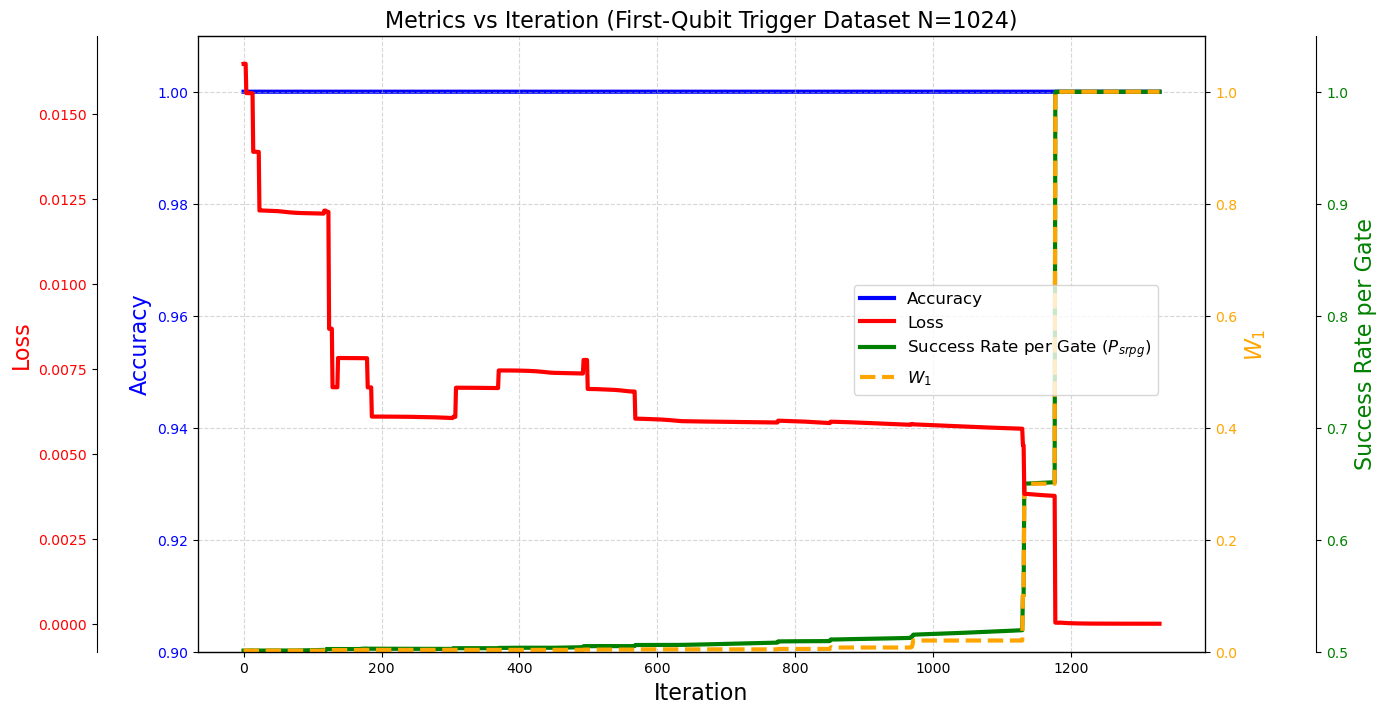

In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define colors for consistency
loss_color = 'red'
acc_color = 'blue'
srpq_color = 'green'
w_color = 'orange'

# Assuming your data is in a DataFrame called 'df'
# df = pd.read_csv('your_data.csv')

fig, ax_acc = plt.subplots(figsize=(13, 8))

# Plot Accuracy
ax_acc.plot(df.index, df['acc'], linewidth=3, label='Accuracy', color=acc_color, zorder=1)
ax_acc.set_xlabel('Iteration', fontsize=16)
ax_acc.set_ylabel('Accuracy', fontsize=16, color=acc_color)
ax_acc.tick_params(axis='y', labelcolor=acc_color)
ax_acc.grid(True, linestyle='--', alpha=0.5)
ax_acc.set_ylim(0.9, 1.01)

# Plot SRPQ on a second axis (right) with log transformation
ax_right = ax_acc.twinx()
ax_right.spines['right'].set_position(('outward', 80))
# ax_right.spines['right'].set_color(srpq_color)
ax_right.plot(df.index, df['srpq'], linewidth=3, label='Success Rate per Gate ($P_{srpg}$)', color=srpq_color, zorder=1)
ax_right.set_ylabel('Success Rate per Gate', fontsize=16, color=srpq_color)
ax_right.tick_params(axis='y', labelcolor=srpq_color)
ax_right.set_ylim(0.5, 1.05)

# Plot W Value on another twin axis with dashed line
ax_w = ax_acc.twinx()
ax_w.plot(df.index, df['w_value'], linewidth=3, linestyle='--', label='$W_1$', color=w_color, zorder=1)
ax_w.set_ylabel('$W_1$', fontsize=16, color=w_color)
ax_w.tick_params(axis='y', labelcolor=w_color)
ax_w.set_ylim(0, 1.1)


# Plot Loss on another twin axis with dashed line
ax_loss = ax_acc.twinx()
ax_loss.spines['left'].set_position(('axes', -0.1))
ax_loss.yaxis.tick_left()
ax_loss.yaxis.set_label_position('left')
# ax_loss.spines['left'].set_color(loss_color)
ax_loss.spines["left"].set_visible(True)
ax_loss.plot(df.index, df['loss'], linewidth=3, linestyle='-', label='Loss', color=loss_color, zorder=1)
ax_loss.set_ylabel('Loss', fontsize=16, color=loss_color)
ax_loss.tick_params(axis='y', labelcolor=loss_color)

# Collect all lines and labels
lines_acc, labels_acc = ax_acc.get_legend_handles_labels()
lines_loss, labels_loss = ax_loss.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
lines_w, labels_w = ax_w.get_legend_handles_labels()

lines = lines_acc + lines_loss + lines_right + lines_w
labels = labels_acc + labels_loss + labels_right + labels_w

# Adjust top to make room for the legend
# fig.subplots_adjust(top=0.85)

# Create a single legend at figure level (above the axes)
legend = fig.legend(lines, labels,
                    loc='center right',     # place it at the top center
                    bbox_to_anchor=(0.87, 0.5),  # fine-tune vertical position
                    # ncol=3,                 # number of columns if you want them side by side
                    fontsize=12,
                    frameon=True,
                    facecolor='white')
legend.set_zorder(10)  # Bring legend to the front in case lines overlap

ax_acc.set_title('Metrics vs Iteration (First-Qubit Trigger Dataset N=1024)', fontsize=16)
plt.show()


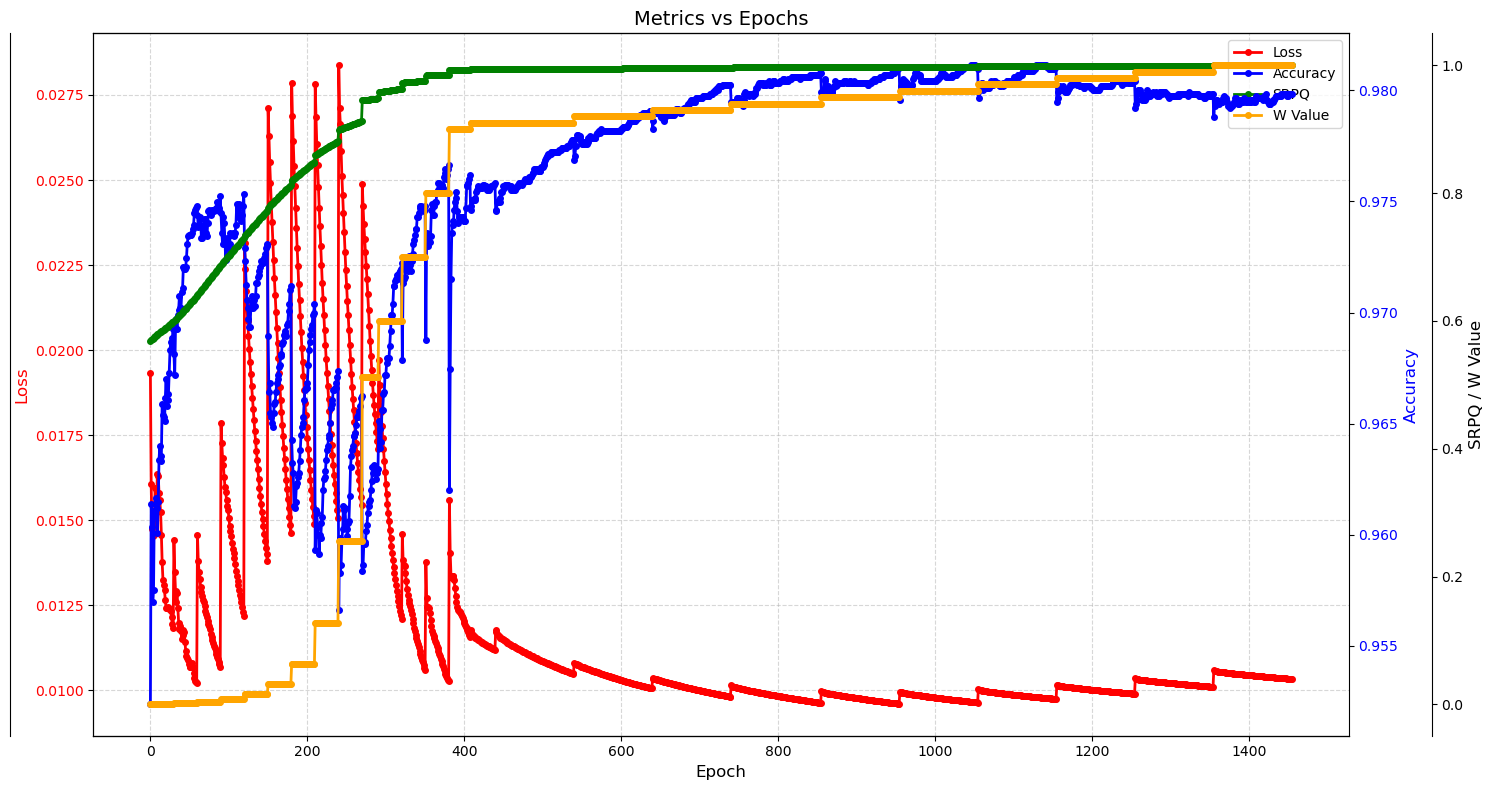

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Define colors for consistency
loss_color = 'red'
acc_color = 'blue'
srpq_color = 'green'
w_color = 'orange'

# Assuming your data is in a DataFrame called 'df'
# For example, if loading from CSV:
# df = pd.read_csv('your_data.csv')

# Create the base figure and axis for Loss
fig, ax_loss = plt.subplots(figsize=(15, 8))

# Plot Loss on the left y-axis
ax_loss.plot(df.index, df['avg_loss'], marker='o', linewidth=2, markersize=4,
             label='Loss', color=loss_color)
ax_loss.set_xlabel('Epoch', fontsize=12)
ax_loss.set_ylabel('Loss', fontsize=12, color=loss_color)
ax_loss.tick_params(axis='y', labelcolor=loss_color)
ax_loss.grid(True, linestyle='--', alpha=0.5)

# Create a second y-axis for Accuracy on the left side
ax_acc = ax_loss.twinx()  # start with a twin axis (defaults to right)
ax_acc.spines['left'].set_position(('outward', 60))  # move its spine to the left
ax_acc.spines['right'].set_visible(False)            # hide the default right spine
ax_acc.plot(df.index, df['avg_acc'], marker='o', linewidth=2, markersize=4,
            label='Accuracy', color=acc_color)
ax_acc.set_ylabel('Accuracy', fontsize=12, color=acc_color)
ax_acc.tick_params(axis='y', labelcolor=acc_color)

# Create a third axis for SRPQ and W Value on the right side
ax_right = ax_loss.twinx()  # this axis stays on the right
ax_right.spines['right'].set_position(('outward', 60))  # offset from the border if needed
ax_right.plot(df.index, df['avg_srpq'], marker='o', linewidth=2, markersize=4,
              label='SRPQ', color=srpq_color)
ax_right.plot(df.index, df['w_value'], marker='o', linewidth=2, markersize=4,
              label='W Value', color=w_color)
ax_right.set_ylabel('SRPQ / W Value', fontsize=12)
# (Optionally, you can set tick_params for ax_right if you want a specific color or style.)

# Combine legends from all axes
lines_loss, labels_loss = ax_loss.get_legend_handles_labels()
lines_acc, labels_acc = ax_acc.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
lines = lines_loss + lines_acc + lines_right
labels = labels_loss + labels_acc + labels_right
ax_loss.legend(lines, labels, loc='upper right')

ax_loss.set_title('Metrics vs Epochs', fontsize=14)
plt.tight_layout()
plt.show()
